# Programming in Python II - Final Coding Project

Author: Denys Siianchuk

Student ID: K12456319

Save this file under a file name in the format k+matriculation_number.ipynb, e.g. *k1234567.ipynb*. Remember that for final submission all code cells must run without errors and all cells have to be evaluated.

The code cells are a basic scaffold - you can of course add new code cells if necessary. However, stick to the overall structure of the template to facilitate grading. Ensure to comment your code and structure it reasonably.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
import pandas as pd

# Setting device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")

# Set random seeds for reproducibility
seed = 1
np.random.seed(seed)

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)

In [2]:
# checking successful setup
print(f"Using device: {device}")

Using device: cuda


In [3]:
# For visualization in Jupyter notebooks
%matplotlib inline

In [4]:
# Set working directory to the project folder
os.chdir("/home/convidium/Desktop/python_2/cnn_image_classifier")  # Change this to your project folder path
print(f"Current working directory: {os.getcwd()}")

Current working directory: /home/convidium/Desktop/python_2/cnn_image_classifier


In [5]:
# creating folder 'assets' if necessary
os.makedirs("assets", exist_ok=True)

## Data Handling and Pre-Processing

In [6]:
def preprocess(data_folder: str) -> tuple[pd.DataFrame, dict]:
    img_classes = [d for d in os.listdir(data_folder) if os.path.isdir(os.path.join(data_folder, d))]

    label_dict = {cls_name: idx for idx, cls_name in enumerate(img_classes)}

    dataset = []

    for img_class_name in img_classes:
        img_class_folder = os.path.join(data_folder, img_class_name)

        for file_name in os.listdir(img_class_folder):
            folder_path = f"{os.path.basename(data_folder)}/{img_class_name}"

            dataset.append({
                'folder': folder_path,
                'file_name': file_name,
                'label': label_dict[img_class_name]
            })

    df = pd.DataFrame(dataset)
    return df, label_dict
    

dataset, label_dict = preprocess("data/train_data")

In [62]:
# checking successful dataframe loading

# uncomment after preprocessing the dataset and adapt the variable name
print(f"Length of dataset: {len(dataset)}") # Should be 10000

Length of dataset: 10000


In [7]:
# your code goes here (splitting train/validation datasets)
train_dataset, val_dataset = train_test_split(
    dataset, 
    test_size=0.2, 
    stratify=dataset['label'], 
    random_state=seed
)

train_dataset["label"].value_counts()

label
7    800
9    800
1    800
6    800
8    800
3    800
0    800
2    800
4    800
5    800
Name: count, dtype: int64

## Exploratory Data Analysis (EDA)

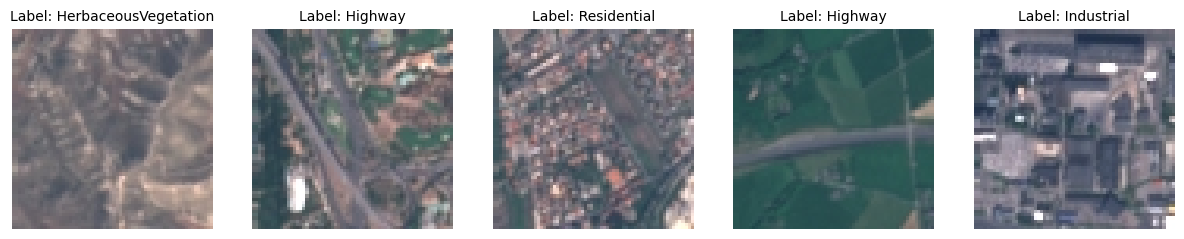

In [8]:
# your code goes here (show_samples)
def show_samples(df: pd.DataFrame, num_samples: int = 5) -> None:
    sample_set = df.sample(num_samples, random_state=seed)

    fig, ax = plt.subplots(1, num_samples, figsize=(15, 6))

    sample_paths = sample_set["folder"].to_numpy()
    sample_names = sample_set["file_name"].to_numpy()

    sample_full_paths = "data/" + sample_paths + "/" + sample_names
    for i in range(len(sample_full_paths)):
        read_image_data = plt.imread(sample_full_paths[i])
        ax[i].imshow(read_image_data)
        ax[i].axis(False)
        ax[i].set_title(f"Label: {sample_names[i].split("_")[0]}", fontsize=10)
    fig.savefig("assets/plots/random_samples.png")
    return

show_samples(dataset, 5)

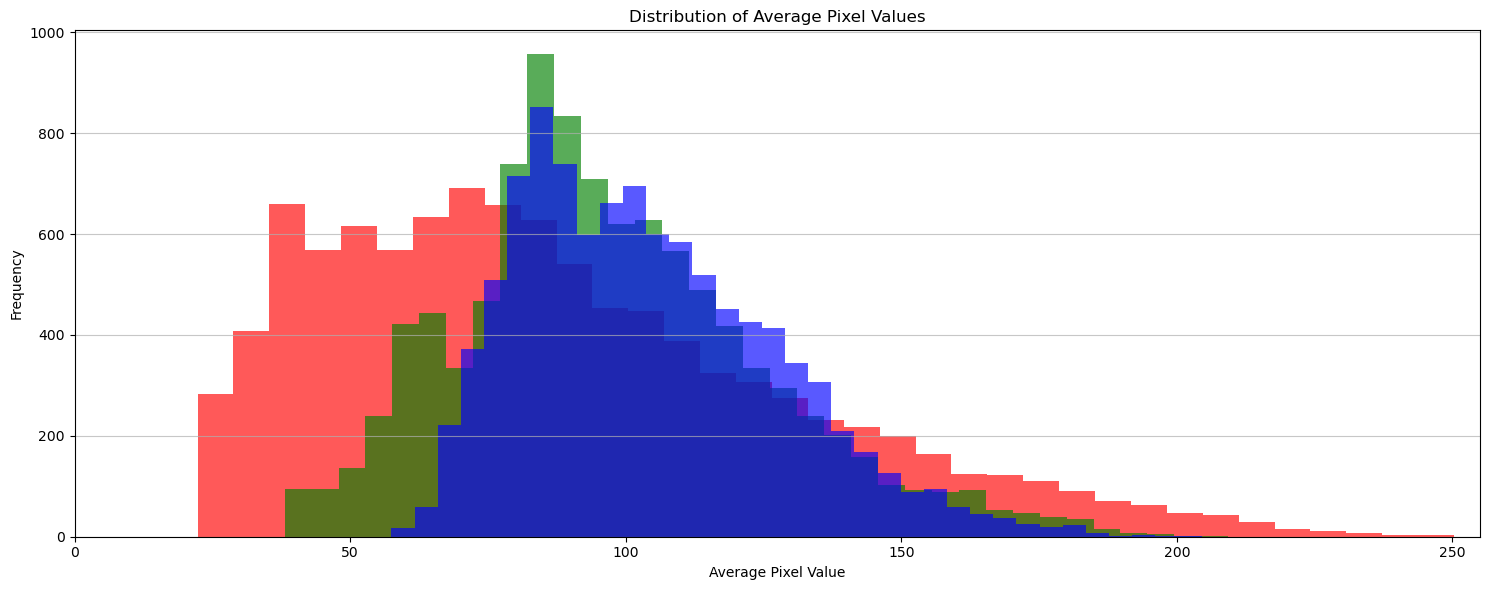

In [ ]:
# your code goes here (average_pixel_plot)
def average_pixel_plot(df: pd.DataFrame) -> None:
    mean_red = []
    mean_green = []
    mean_blue = []

    for index, sample in df.iterrows():
        sample_full_path = f"data/{sample['folder']}/{sample['file_name']}"
        img = plt.imread(sample_full_path)
    
        channels_mean = img.mean(axis=(0, 1))
    
        mean_red.append(channels_mean[0])
        mean_green.append(channels_mean[1])
        mean_blue.append(channels_mean[2])



    fig, ax = plt.subplots(figsize=(15, 6))

    ax.hist(mean_red, bins=35, alpha=0.65, color='red', label='Red Channel')
    ax.hist(mean_green, bins=35, alpha=0.65, color='green', label='Green Channel')
    ax.hist(mean_blue, bins=35, alpha=0.65, color='blue', label='Blue Channel')

    ax.set_title("Distribution of Average Pixel Values")
    ax.set_xlabel("Average Pixel Value")
    ax.set_ylabel("Frequency")

    ax.grid(axis='y', linestyle='-', alpha=0.7)
    ax.set_xlim(0, 255)
    fig.tight_layout()
    os.makedirs("assets/plots", exist_ok=True)
    fig.savefig("assets/plots/average_pixel_distribution.png")
    plt.show()
    
    return

average_pixel_plot(dataset)

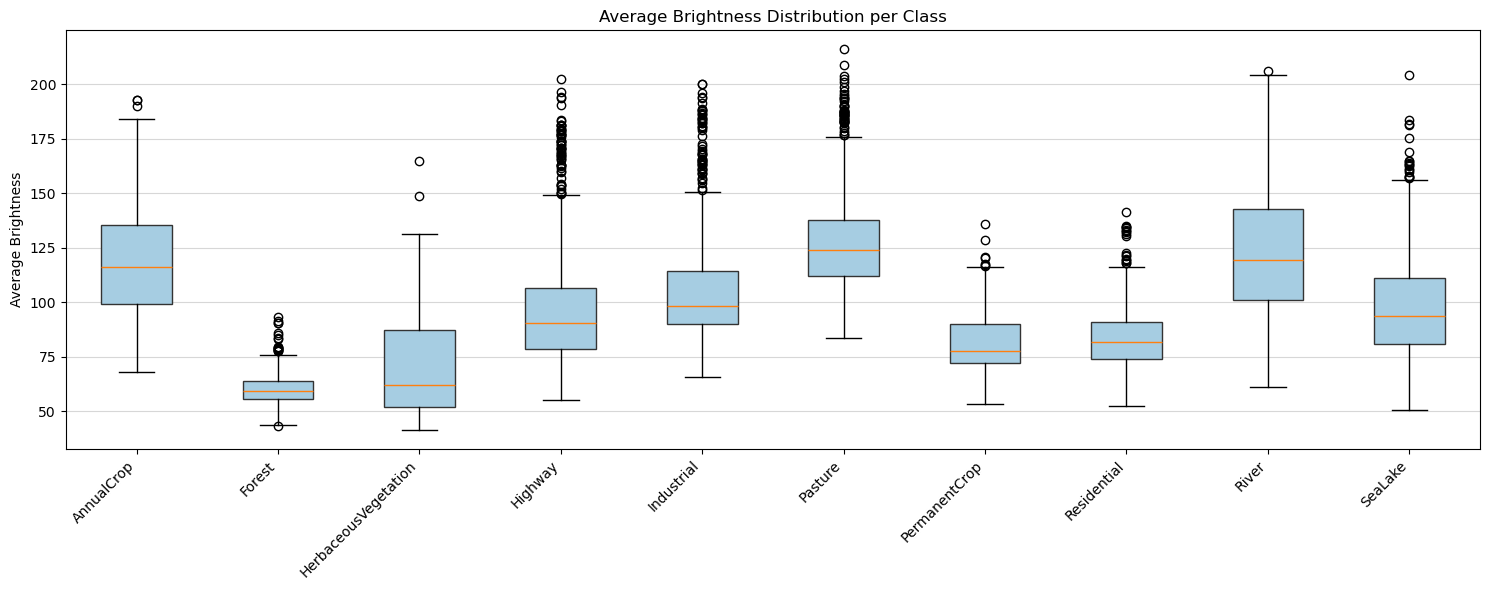

In [33]:
# your code goes here (average_brightness_per_class)
def average_brightness_per_class(df: pd.DataFrame) -> None:
    df_working = df.copy()
    brightness_values = []

    classes = sorted(label_dict.keys())
    data_to_plot = []

    for name, group in df_working.groupby('label'):
        group_brightness_list = []
    
        for index, sample in group.iterrows():
            sample_full_path = f"data/{sample['folder']}/{sample['file_name']}"
            img = plt.imread(sample_full_path)
            img_brightness = img.mean()

            group_brightness_list.append(img_brightness)

        data_to_plot.append(np.array(group_brightness_list))
    
    fig, ax = plt.subplots(figsize=(15, 6))
    
    ax.boxplot(data_to_plot, labels=classes, patch_artist=True,boxprops=dict(facecolor='#a6cde2', color='#333333', linewidth=1),)
    
    ax.set_title("Average Brightness Distribution per Class")
    ax.set_ylabel("Average Brightness")
    ax.grid(axis='y', linestyle='-', alpha=0.5)
    
    ax.set_xticklabels(classes, rotation=45, ha='right')
    
    fig.tight_layout()
    
    os.makedirs("assets/plots", exist_ok=True)
    fig.savefig("assets/plots/average_brightness.png")
    
    plt.show()

average_brightness_per_class(dataset)

## CNN Implementation and Training

### Dataset class

In [ ]:
# your code goes here

### Data Loaders

In [ ]:
# your code goes here

### Model Architecture

In [ ]:
# your code goes here

### Training Loop

In [ ]:
# your code goes here

## Model Evaluation

In [ ]:
# your code goes here (plot_training_curves)

In [ ]:
# your code goes here (plot_confusion_matrix)

In [ ]:
# your code goes here (plot_misclassified_samples)

### Test Set

In [ ]:
# your code goes here (preprocess_test_data)

In [ ]:
# your code goes here (create dataset and dataloader)

In [ ]:
# your code goes here (evaluate model on test set)

In [ ]:
# your code goes here (create submission csv file for challenge server)